## ML - Supervised Learning
***Linear Regression***

In [1]:
#Import the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Read the salary dataset
data = {'Experience': [5,8,10,15,25,30],
        'Salary': [10,20,80,100,120,180]}
df = pd.DataFrame(data)
print(df)

   Experience  Salary
0           5      10
1           8      20
2          10      80
3          15     100
4          25     120
5          30     180


In [3]:
#Create feature variable(X) and target variable(Y)
X = df['Experience'].values.reshape(-1,1)
print('X_variable',X)

Y = df['Salary'].values.reshape(-1,1)
print('Y_variable',Y)

X_variable [[ 5]
 [ 8]
 [10]
 [15]
 [25]
 [30]]
Y_variable [[ 10]
 [ 20]
 [ 80]
 [100]
 [120]
 [180]]


In [4]:
#Calculate the mean
x_mean = np.mean(X)
print(f'X-Mean: {x_mean:.2f}')
y_mean = np.mean(Y)
print(f'Y-Mean: {y_mean:.2f}')

X-Mean: 15.50
Y-Mean: 85.00


### Calculate the slope (m)
#### Slope tells how much y changes when x increases by 1 unit
#### Slope = Change in Y / Change in X

In [5]:
change_in_Y = np.sum((X - x_mean) * (Y - y_mean))
change_in_X = np.sum((X - x_mean) ** 2)
m = change_in_Y / change_in_X
print(f'Slope (m): {m:.2f}')

Slope (m): 6.04


### Calculate the Intercept (b)

In [6]:
b = y_mean - (m * x_mean)
print(f'Intercept(b): {b:.2f}')

Intercept(b): -8.62


### Predict Salary based on the new experience input using Linear regression
#### salary = m * (Experience) + b

In [7]:
# Predict salary for a new employee
new_experience = 25
regression_line  = m * new_experience + b
print(f'Prediction {regression_line.round().astype(int)}')

Prediction 142


   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
Slope: 9423.81532303098
Intercept: 24380.20147947369
Prediction:  [115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]
R² Score: 0.9024461774180498
Mean Squared Error: 49830096.855908334


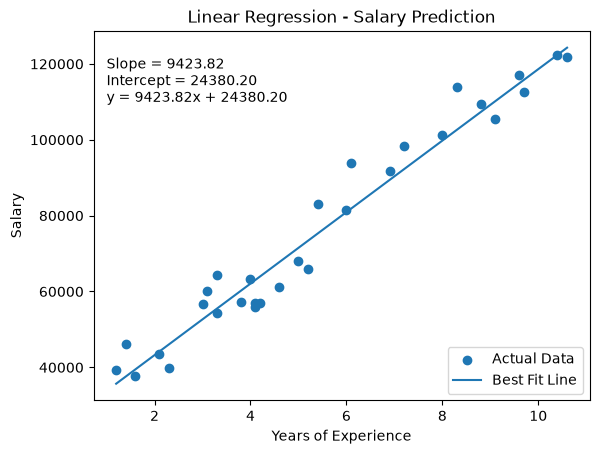

In [9]:
#Import machine learning libraries from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("Salary_dataset.csv")
df = df.drop('Unnamed: 0', axis=1)

# 2. Inspect dataset
print(df.head())
print(df.info())

# 3. Select X and Y
X = df[['YearsExperience']]
Y = df['Salary']

# 4. Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# 5. Create model
model = LinearRegression()

# 6. Train model
model.fit(X_train, Y_train)

# 7. Get slope and intercept
m = model.coef_[0]
b = model.intercept_

print("Slope:", m)
print("Intercept:", b)

# 8. Prediction
Y_pred = model.predict(X_test)
print('Prediction: ',Y_pred)

# 9. Evaluation
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

# 10. Visualization
plt.scatter(X, Y, label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    label='Best Fit Line'
)

# 11. Display equation
equation = f"y = {m:.2f}x + {b:.2f}"

plt.text(
    1,
    110000,
    f"Slope = {m:.2f}\n"
    f"Intercept = {b:.2f}\n"
    f"{equation}"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression - Salary Prediction")

plt.legend()
plt.show()